OrderedDict([('fc1.weight', tensor([[-6.3415, -5.8919],
        [ 2.0674,  1.3813],
        [-2.6256, -2.8806],
        [-4.5906, -3.9281],
        [-3.2062, -3.7370],
        [-0.5101, -0.4293]])), ('fc1.bias', tensor([-6.5117, -4.2887, -2.9355, -4.2503, -3.1916, -0.4105])), ('fc2.weight', tensor([[ 5.7619,  1.4560, -2.4503, -4.3291, -3.7221, -0.2463]])), ('fc2.bias', tensor([6.1172]))]) 



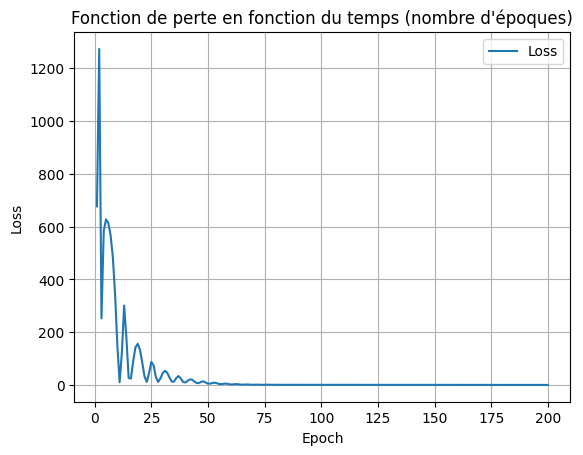

tensor([[47.1822],
        [ 6.1172],
        [54.1198]])


In [3]:
#Model de résolution d'une équation simple 3X1 + 2X2
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import random
import torch 


# Données d'entraînement
train = {
    'x1': [],
    'x2': [],
    'y': []
}

losses = []

# Itérer 1000 fois pour générer les données d'entraînement
for _ in range(900):
    # Générer des valeurs aléatoires pour x1 et x2 (entre 0 et 10)
    x1 = random.uniform(0, 10)
    x2 = random.uniform(0, 10)
    
    # Calculer la valeur de y selon la formule y = 3*x1 + 2*x2
    y = 3*x1 + 2*x2
    
    # Ajouter les valeurs au dictionnaire d'entraînement
    train['x1'].append(x1)
    train['x2'].append(x2)
    train['y'].append(y)

#print(train)

# Données de prédiction
predict = {
    'x1': [0.35, 0.15, 8],
    'x2': [23, 2, 15],
}

train_df = pd.DataFrame(train)
predict_df = pd.DataFrame(predict)

# Convertir les données d'entraînement et les étiquettes en tenseurs
train_tensor = torch.tensor(train_df[['x1', 'x2']].values, dtype=torch.float32)
train_label_tensor = torch.tensor(train_df['y'].values, dtype=torch.float32)

# Convertir les données de prédiction en tenseur
predict_tensor = torch.tensor(predict_df[['x1', 'x2']].values, dtype=torch.float32)

# Définir le modèle du régresseur simple
class SimpleRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRegressor, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

input_size = 2
hidden_size = 6
output_size = 1

model = SimpleRegressor(input_size, hidden_size, output_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1)

# Mettre le modèle en mode d'entraînement
model.train()

# Boucle d'entraînement
num_epochs = 200  # Augmenter le nombre d'époques pour de meilleures performances

for epoch in range(num_epochs):
    # Passer les données dans le modèle
    outputs = model(train_tensor)

    # Calculer la perte
    loss = criterion(outputs.squeeze(), train_label_tensor)

    # Réinitialiser les gradients, effectuer la rétropropagation et mettre à jour les poids
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Afficher la perte à chaque époque
    #print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
    losses.append(loss.item())

model_params = model.state_dict()

print(model_params, "\n")

plt.plot(range(1, num_epochs+1), losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fonction de perte en fonction du temps (nombre d\'époques)')
plt.legend()
plt.grid(True)
plt.show()  

htnnieklf,

# Mettre le modèle en mode d'évaluation
model.eval()

# Passer les nouvelles données dans le modèle pour obtenir les prédictions
with torch.no_grad():
    predictions = model(predict_tensor)

# Afficher les prédictions
print(predictions)
